In [111]:
%pip install -q numpy pandas matplotlib scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [112]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder



print("Libraries imported successfully.")

Libraries imported successfully.


In [113]:
df = pd.read_csv('File_Path.csv')
print("Shape:", df.shape)

Shape: (42000, 785)


In [114]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## EDA

In [115]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [117]:
class_counts = df["label"].value_counts().sort_index()

print(class_counts)

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


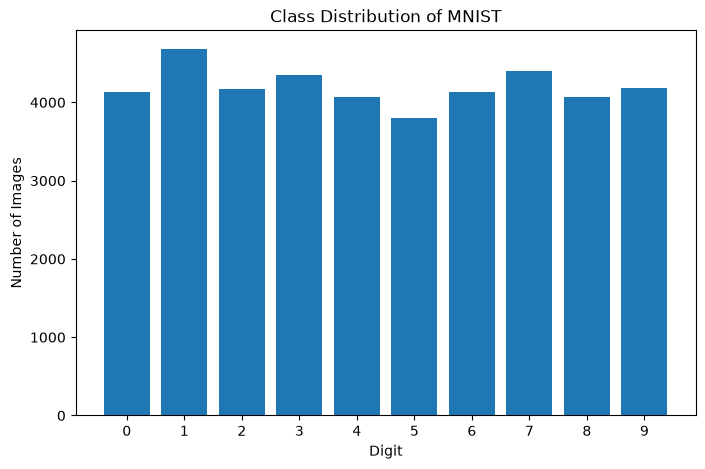

In [118]:
plt.figure(figsize=(8, 5))

plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Class Distribution of MNIST")

plt.xticks(range(10))
plt.show()

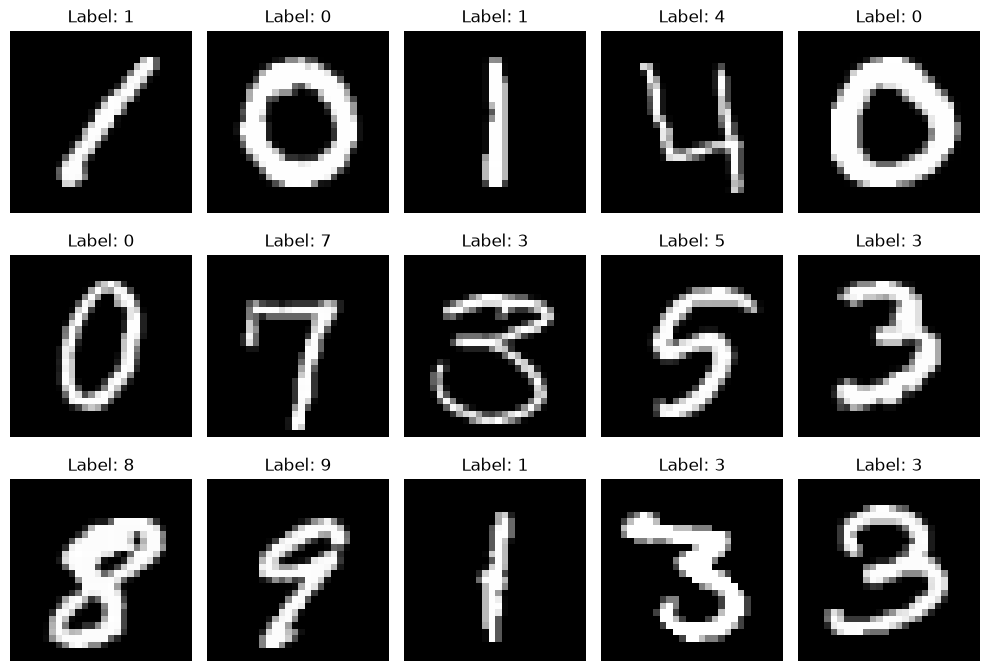

In [119]:
X_pixels = df.drop("label", axis=1).values
y = df["label"].values

fig, axes = plt.subplots(3, 5, figsize=(10, 7))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_pixels[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [120]:
X = df.drop("label", axis=1).values
y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (42000, 784)
y shape: (42000,)


In [121]:
X = X.astype(np.float32) / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [122]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set   :", X_train.shape, y_train.shape)
print("Validation set :", X_val.shape, y_val.shape)
print("Testing set    :", X_test.shape, y_test.shape)

Training set   : (33600, 784) (33600,)
Validation set : (4200, 784) (4200,)
Testing set    : (4200, 784) (4200,)


In [123]:
encoder = OneHotEncoder(sparse_output=False)

y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_val_onehot = encoder.transform(y_val.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

print("y_train shape:", y_train_onehot.shape)
print("y_val shape  :", y_val_onehot.shape)
print("y_test shape :", y_test_onehot.shape)

y_train shape: (33600, 10)
y_val shape  : (4200, 10)
y_test shape : (4200, 10)


## MLP Building Blocks

In [124]:
architecture = [784, 128, 64, 10]

In [125]:

def cross_entropy_loss(y_true, y_pred):

    epsilon = 1e-12

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        np.sum(y_true * np.log(y_pred), axis=1)
    )

    return loss

In [126]:

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [127]:
def relu_derivative(Z):
    return (Z > 0).astype(float)

In [128]:

def relu(Z):
    return np.maximum(0, Z)

In [129]:
def initialize_parameters(architecture):
    
    parameters = {}
    
    for layer in range(1, len(architecture)):
        
        input_neurons = architecture[layer - 1]
        output_neurons = architecture[layer]
        
        # Xavier initialization
        parameters[f"W{layer}"] = (
            np.random.randn(input_neurons, output_neurons)
            * np.sqrt(1 / input_neurons)
        )
        
        parameters[f"b{layer}"] = np.zeros(
            (1, output_neurons)
        )
    
    return parameters

In [130]:
parameters = initialize_parameters(architecture)

In [131]:
for key, value in parameters.items():
    print(key, value.shape)

W1 (784, 128)
b1 (1, 128)
W2 (128, 64)
b2 (1, 64)
W3 (64, 10)
b3 (1, 10)


In [132]:
def forward_propagation(X, parameters):

    cache = {}

    A = X

    number_of_layers = len(parameters) // 2

    for layer in range(1, number_of_layers + 1):

        W = parameters[f"W{layer}"]
        b = parameters[f"b{layer}"]

        Z = np.dot(A, W) + b

        # Hidden layers
        if layer < number_of_layers:
            A = relu(Z)

        # Output layer
        else:
            A = softmax(Z)

        cache[f"Z{layer}"] = Z
        cache[f"A{layer}"] = A

    return A, cache

In [133]:
architecture = [784, 128, 64, 10]

parameters = initialize_parameters(architecture)

X_sample = X_train[:32]

output, cache = forward_propagation(
    X_sample,
    parameters
)

print("Input shape :", X_sample.shape)
print("Output shape:", output.shape)

Input shape : (32, 784)
Output shape: (32, 10)


In [134]:
def backward_propagation(X, y_true, parameters, cache):
    
    gradients = {}
    
    number_of_layers = len(parameters) // 2
    m = X.shape[0]
    

    
    A_last = cache[f"A{number_of_layers}"]
    
    
    dZ = A_last - y_true
    
    
    A_previous = cache[f"A{number_of_layers - 1}"] \
                 if number_of_layers > 1 else X
    
    W_last = parameters[f"W{number_of_layers}"]
    
    gradients[f"dW{number_of_layers}"] = (
        np.dot(A_previous.T, dZ) / m
    )
    
    gradients[f"db{number_of_layers}"] = (
        np.sum(dZ, axis=0, keepdims=True) / m
    )
    
    
    dA = np.dot(dZ, W_last.T)

    for layer in reversed(range(1, number_of_layers)):
        
        Z = cache[f"Z{layer}"]
        
        dZ = dA * relu_derivative(Z)
        
        
        if layer == 1:
            A_previous = X
        else:
            A_previous = cache[f"A{layer - 1}"]
        
        gradients[f"dW{layer}"] = (
            np.dot(A_previous.T, dZ) / m
        )
        
        gradients[f"db{layer}"] = (
            np.sum(dZ, axis=0, keepdims=True) / m
        )
        
       
        W = parameters[f"W{layer}"]
        
        dA = np.dot(dZ, W.T)
    
    return gradients

In [135]:
X_sample = X_train[:32]
y_sample = y_train_onehot[:32]

output, cache = forward_propagation(
    X_sample,
    parameters
)

loss = cross_entropy_loss(
    y_sample,
    output
)

gradients = backward_propagation(
    X_sample,
    y_sample,
    parameters,
    cache
)

print("Loss:", loss)

print("\nGradients:")

for key, value in gradients.items():
    print(key, value.shape)

Loss: 2.316284274958246

Gradients:
dW3 (64, 10)
db3 (1, 10)
dW2 (128, 64)
db2 (1, 64)
dW1 (784, 128)
db1 (1, 128)


In [136]:


def update_parameters(parameters, gradients, learning_rate):
    
    number_of_layers = len(parameters) // 2
    
    for layer in range(1, number_of_layers + 1):
        
        parameters[f"W{layer}"] -= (
            learning_rate * gradients[f"dW{layer}"]
        )
        
        parameters[f"b{layer}"] -= (
            learning_rate * gradients[f"db{layer}"]
        )
    
    return parameters

In [137]:
learning_rate = 0.01

parameters = update_parameters(
    parameters,
    gradients,
    learning_rate
)

print("Parameters updated successfully.")

Parameters updated successfully.


In [138]:
X_sample = X_train[:128]
y_sample = y_train_onehot[:128]

output_before, cache_before = forward_propagation(
    X_sample,
    parameters
)

loss_before = cross_entropy_loss(
    y_sample,
    output_before
)


gradients = backward_propagation(
    X_sample,
    y_sample,
    parameters,
    cache_before
)


parameters = update_parameters(
    parameters,
    gradients,
    learning_rate=0.01
)

output_after, cache_after = forward_propagation(
    X_sample,
    parameters
)

loss_after = cross_entropy_loss(
    y_sample,
    output_after
)

print("Loss before update:", loss_before)
print("Loss after update :", loss_after)

Loss before update: 2.322083429469692
Loss after update : 2.3170822576971997


In [139]:
architecture = [784, 256, 128, 64, 32, 10]

In [140]:
parameters = initialize_parameters(architecture)

In [141]:
for key, value in parameters.items():
    print(key, value.shape)

W1 (784, 256)
b1 (1, 256)
W2 (256, 128)
b2 (1, 128)
W3 (128, 64)
b3 (1, 64)
W4 (64, 32)
b4 (1, 32)
W5 (32, 10)
b5 (1, 10)


In [142]:
output, cache = forward_propagation(
    X_sample,
    parameters
)

print(output.shape)

(128, 10)


In [143]:
gradients = backward_propagation(
    X_sample,
    y_sample,
    parameters,
    cache
)

for key, value in gradients.items():
    print(key, value.shape)

dW5 (32, 10)
db5 (1, 10)
dW4 (64, 32)
db4 (1, 32)
dW3 (128, 64)
db3 (1, 64)
dW2 (256, 128)
db2 (1, 128)
dW1 (784, 256)
db1 (1, 256)


In [144]:

def predict(X, parameters):
    
    probabilities, _ = forward_propagation(
        X,
        parameters
    )
    
    predictions = np.argmax(
        probabilities,
        axis=1
    )
    
    return predictions

In [145]:
predictions = predict(
    X_test[:20],
    parameters
)

print("Predictions:", predictions)
print("Actual     :", y_test[:20])

Predictions: [4 5 4 3 9 3 2 9 2 4 3 7 4 9 3 9 4 3 9 4]
Actual     : [9 1 5 3 6 0 7 5 7 1 6 1 4 8 6 9 9 6 6 4]


In [146]:
def accuracy(y_true, y_pred):
    
    return np.mean(y_true == y_pred)

In [147]:
predictions = predict(
    X_test,
    parameters
)

test_accuracy = accuracy(
    y_test,
    predictions
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.10904761904761905


## Checking the Gradients


In [148]:

def numerical_gradient(
    X,
    y,
    parameters,
    parameter_name,
    epsilon=1e-5
):
    
    numerical_grads = np.zeros_like(
        parameters[parameter_name]
    )
    
    parameter = parameters[parameter_name]
    
    
    for index in np.ndindex(parameter.shape):
        
        
        original_value = parameter[index]
        
       
        
        parameter[index] = original_value + epsilon
        
        output_plus, _ = forward_propagation(
            X,
            parameters
        )
        
        loss_plus = cross_entropy_loss(
            y,
            output_plus
        )
        
      
        
        parameter[index] = original_value - epsilon
        
        output_minus, _ = forward_propagation(
            X,
            parameters
        )
        
        loss_minus = cross_entropy_loss(
            y,
            output_minus
        )
        
  
        numerical_grads[index] = (
            loss_plus - loss_minus
        ) / (2 * epsilon)
        
        
        parameter[index] = original_value
    
    return numerical_grads

In [149]:
architecture_check = [4, 5, 3]

In [150]:
architecture_check = [4, 5, 3]

parameters_check = initialize_parameters(
    architecture_check
)

print("Parameters:")
for key, value in parameters_check.items():
    print(key, value.shape)

Parameters:
W1 (4, 5)
b1 (1, 5)
W2 (5, 3)
b2 (1, 3)


In [151]:
X_check = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.5, 0.6, 0.7, 0.8],
    [0.9, 0.1, 0.2, 0.3],
    [0.4, 0.5, 0.6, 0.7]
])

y_labels_check = np.array([0, 1, 2, 1])

y_check = np.zeros(
    (len(y_labels_check), 3)
)

y_check[
    np.arange(len(y_labels_check)),
    y_labels_check
] = 1

print("X shape:", X_check.shape)
print("y shape:", y_check.shape)

X shape: (4, 4)
y shape: (4, 3)


In [152]:
output_check, cache_check = forward_propagation(
    X_check,
    parameters_check
)

loss_check = cross_entropy_loss(
    y_check,
    output_check
)

analytical_gradients = backward_propagation(
    X_check,
    y_check,
    parameters_check,
    cache_check
)

print("Loss:", loss_check)

for key, value in analytical_gradients.items():
    print(key, value.shape)

Loss: 1.0784482131688864
dW2 (5, 3)
db2 (1, 3)
dW1 (4, 5)
db1 (1, 5)


In [153]:
numerical_dW1 = numerical_gradient(
    X_check,
    y_check,
    parameters_check,
    "W1"
)

print("Numerical dW1 shape:", numerical_dW1.shape)

Numerical dW1 shape: (4, 5)


In [154]:
print("Analytical dW1:")
print(analytical_gradients["dW1"])

print("\nNumerical dW1:")
print(numerical_dW1)

Analytical dW1:
[[-0.01600848  0.07988649 -0.0283034   0.03082783  0.        ]
 [-0.06736223  0.00887628  0.0280543   0.05226305  0.        ]
 [-0.07523575  0.01775255  0.03176867  0.05967512  0.        ]
 [-0.08310928  0.02662883  0.03548304  0.06708718  0.        ]]

Numerical dW1:
[[-0.01600848  0.07988649 -0.0283034   0.03082783  0.        ]
 [-0.06736223  0.00887628  0.0280543   0.05226305  0.        ]
 [-0.07523575  0.01775255  0.03176867  0.05967512  0.        ]
 [-0.08310928  0.02662883  0.03548304  0.06708718  0.        ]]


In [155]:
def gradient_difference(
    analytical,
    numerical
):
    
    numerator = np.linalg.norm(
        analytical - numerical
    )
    
    denominator = (
        np.linalg.norm(analytical)
        + np.linalg.norm(numerical)
        + 1e-12
    )
    
    return numerator / denominator

In [156]:
difference_W1 = gradient_difference(
    analytical_gradients["dW1"],
    numerical_dW1
)

print("Relative difference for W1:", difference_W1)

Relative difference for W1: 6.67085693487632e-11


In [157]:
for parameter_name in parameters_check.keys():
    
    numerical_grad = numerical_gradient(
        X_check,
        y_check,
        parameters_check,
        parameter_name
    )
    
    analytical_grad = analytical_gradients[
        "d" + parameter_name
    ]
    
    difference = gradient_difference(
        analytical_grad,
        numerical_grad
    )
    
    print(
        f"{parameter_name}: "
        f"{difference:.10e}"
    )

W1: 6.6708569349e-11
b1: 6.8302454111e-11
W2: 5.3206826927e-11
b2: 2.2203260356e-11


In [158]:
def gradient_check(
    X,
    y,
    parameters,
    analytical_gradients,
    epsilon=1e-5,
    threshold=1e-7
):
    
    differences = {}
    
    for parameter_name in parameters.keys():
        
        numerical_grad = numerical_gradient(
            X,
            y,
            parameters,
            parameter_name,
            epsilon
        )
        
        analytical_grad = analytical_gradients[
            "d" + parameter_name
        ]
        
        difference = gradient_difference(
            analytical_grad,
            numerical_grad
        )
        
        differences[parameter_name] = difference
    
    passed = all(
        difference < threshold
        for difference in differences.values()
    )
    
    return differences, passed

In [159]:
differences, passed = gradient_check(
    X_check,
    y_check,
    parameters_check,
    analytical_gradients
)

print("Gradient Check Results")
print("=" * 40)

for parameter, difference in differences.items():
    print(
        f"{parameter}: "
        f"{difference:.10e}"
    )

print("\nGradient Check:", 
      "PASSED" if passed else "FAILED")

Gradient Check Results
W1: 6.6708569349e-11
b1: 6.8302454111e-11
W2: 5.3206826927e-11
b2: 2.2203260356e-11

Gradient Check: PASSED


In [160]:
def create_mini_batches(X, y, batch_size=64):
    
    m = X.shape[0]
    
    # Shuffle indices
    indices = np.random.permutation(m)
    
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    mini_batches = []
    
    for start in range(0, m, batch_size):
        
        end = start + batch_size
        
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]
        
        mini_batches.append(
            (X_batch, y_batch)
        )
    
    return mini_batches

In [161]:
batches = create_mini_batches(
    X_train,
    y_train_onehot,
    batch_size=64
)

print("Number of batches:", len(batches))
print("First batch X:", batches[0][0].shape)
print("First batch y:", batches[0][1].shape)

Number of batches: 525
First batch X: (64, 784)
First batch y: (64, 10)


In [162]:
def train_one_epoch(
    X_train,
    y_train,
    parameters,
    batch_size,
    learning_rate
):
    
    mini_batches = create_mini_batches(
        X_train,
        y_train,
        batch_size
    )
    
    total_loss = 0
    total_samples = 0
    
    for X_batch, y_batch in mini_batches:
  
        predictions, cache = forward_propagation(
            X_batch,
            parameters
        )
   
        batch_loss = cross_entropy_loss(
            y_batch,
            predictions
        )
        
     
        gradients = backward_propagation(
            X_batch,
            y_batch,
            parameters,
            cache
        )
        
     
        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )
        
      
        batch_size_actual = X_batch.shape[0]
        
        total_loss += batch_loss * batch_size_actual
        total_samples += batch_size_actual
    
    epoch_loss = total_loss / total_samples
    
    return parameters, epoch_loss

In [163]:


def evaluate_model(
    X,
    y_onehot,
    y_labels,
    parameters
):
    
    predictions_probability, _ = forward_propagation(
        X,
        parameters
    )
    
    loss = cross_entropy_loss(
        y_onehot,
        predictions_probability
    )
    
    predicted_labels = np.argmax(
        predictions_probability,
        axis=1
    )
    
    accuracy_value = np.mean(
        predicted_labels == y_labels
    )
    
    return loss, accuracy_value

In [164]:


def train(
    X_train,
    y_train_onehot,
    y_train_labels,
    X_val,
    y_val_onehot,
    y_val_labels,
    architecture,
    epochs=20,
    batch_size=64,
    learning_rate=0.01
):
    
    
    parameters = initialize_parameters(
        architecture
    )
    
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
    
    for epoch in range(1, epochs + 1):
        
      
        
        parameters, train_loss = train_one_epoch(
            X_train,
            y_train_onehot,
            parameters,
            batch_size,
            learning_rate
        )

        
        train_loss_full, train_accuracy = evaluate_model(
            X_train,
            y_train_onehot,
            y_train_labels,
            parameters
        )
        
    
        val_loss, val_accuracy = evaluate_model(
            X_val,
            y_val_onehot,
            y_val_labels,
            parameters
        )
        
     
        
        history["train_loss"].append(
            train_loss_full
        )
        
        history["train_accuracy"].append(
            train_accuracy
        )
        
        history["val_loss"].append(
            val_loss
        )
        
        history["val_accuracy"].append(
            val_accuracy
        )
     
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss_full:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )
    
    return parameters, history

## Train the Model

In [165]:
architecture = [784, 50, 50, 50, 50, 10]

In [166]:

parameters, history = train(
    X_train=X_train,
    y_train_onehot=y_train_onehot,
    y_train_labels=y_train,
    
    X_val=X_val,
    y_val_onehot=y_val_onehot,
    y_val_labels=y_val,
    
    architecture=architecture,
    
    epochs=80,
    batch_size=64,
    learning_rate=0.01
)

Epoch 01/80 | Train Loss: 1.4699 | Train Acc: 0.5724 | Val Loss: 1.4711 | Val Acc: 0.5705
Epoch 02/80 | Train Loss: 0.5286 | Train Acc: 0.8471 | Val Loss: 0.5380 | Val Acc: 0.8400
Epoch 03/80 | Train Loss: 0.3894 | Train Acc: 0.8879 | Val Loss: 0.4017 | Val Acc: 0.8824
Epoch 04/80 | Train Loss: 0.3466 | Train Acc: 0.8977 | Val Loss: 0.3640 | Val Acc: 0.8919
Epoch 05/80 | Train Loss: 0.3200 | Train Acc: 0.9070 | Val Loss: 0.3468 | Val Acc: 0.8964
Epoch 06/80 | Train Loss: 0.2967 | Train Acc: 0.9146 | Val Loss: 0.3253 | Val Acc: 0.9038
Epoch 07/80 | Train Loss: 0.2684 | Train Acc: 0.9236 | Val Loss: 0.2976 | Val Acc: 0.9140
Epoch 08/80 | Train Loss: 0.2500 | Train Acc: 0.9281 | Val Loss: 0.2797 | Val Acc: 0.9160
Epoch 09/80 | Train Loss: 0.2375 | Train Acc: 0.9304 | Val Loss: 0.2678 | Val Acc: 0.9207
Epoch 10/80 | Train Loss: 0.2201 | Train Acc: 0.9368 | Val Loss: 0.2499 | Val Acc: 0.9262
Epoch 11/80 | Train Loss: 0.2026 | Train Acc: 0.9408 | Val Loss: 0.2386 | Val Acc: 0.9302
Epoch 12/8

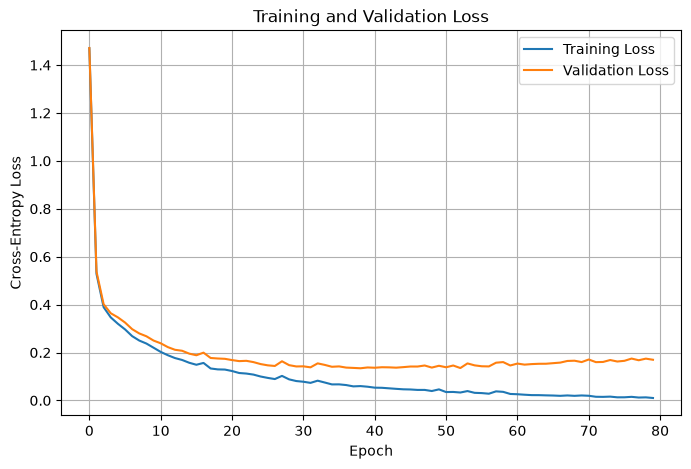

In [167]:

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

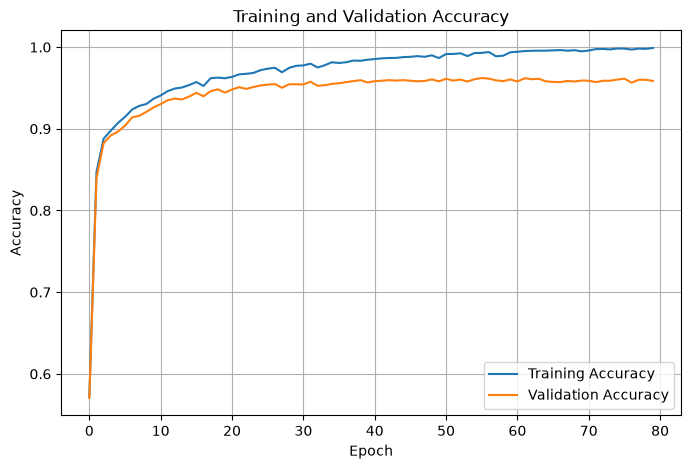

In [168]:


plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

In [169]:

test_loss, test_accuracy = evaluate_model(
    X_test,
    y_test_onehot,
    y_test,
    parameters
)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

Test Loss     : 0.16222407700744845
Test Accuracy : 0.9621428571428572


## Regularization

In [170]:

def cross_entropy_loss(
    y_true,
    y_pred,
    parameters=None,
    l2_lambda=0.0
):
    
    epsilon = 1e-12
    
    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )
    
    # Cross entropy
    data_loss = -np.mean(
        np.sum(
            y_true * np.log(y_pred),
            axis=1
        )
    )
    
    # L2 penalty
    regularization_loss = 0.0
    
    if parameters is not None and l2_lambda > 0:
        
        for key, value in parameters.items():
            
            if key.startswith("W"):
                
                regularization_loss += np.sum(
                    value ** 2
                )
        
        m = y_true.shape[0]
        
        regularization_loss *= (
            l2_lambda / (2 * m)
        )
    
    return data_loss + regularization_loss

In [171]:
def backward_propagation(
    X,
    y_true,
    parameters,
    cache,
    l2_lambda=0.0
):
    
    gradients = {}
    
    number_of_layers = len(parameters) // 2
    m = X.shape[0]
    
    # Output layer
    A_last = cache[f"A{number_of_layers}"]
    
    dZ = A_last - y_true
    
    A_previous = (
        cache[f"A{number_of_layers - 1}"]
        if number_of_layers > 1
        else X
    )
    
    W_last = parameters[f"W{number_of_layers}"]
    
    dW = np.dot(
        A_previous.T,
        dZ
    ) / m
    
    # L2 regularization
    dW += (l2_lambda / m) * W_last
    
    gradients[f"dW{number_of_layers}"] = dW
    
    gradients[f"db{number_of_layers}"] = (
        np.sum(dZ, axis=0, keepdims=True) / m
    )
    
    dA = np.dot(
        dZ,
        W_last.T
    )
    
    # Hidden layers
    for layer in reversed(
        range(1, number_of_layers)
    ):
        
        Z = cache[f"Z{layer}"]
        
        dZ = (
            dA *
            relu_derivative(Z)
        )
        
        A_previous = (
            X
            if layer == 1
            else cache[f"A{layer - 1}"]
        )
        
        W = parameters[f"W{layer}"]
        
        dW = np.dot(
            A_previous.T,
            dZ
        ) / m
        
        # L2 regularization
        dW += (l2_lambda / m) * W
        
        gradients[f"dW{layer}"] = dW
        
        gradients[f"db{layer}"] = (
            np.sum(
                dZ,
                axis=0,
                keepdims=True
            ) / m
        )
        
        dA = np.dot(
            dZ,
            W.T
        )
    
    return gradients

In [172]:

def cross_entropy_loss(
    y_true,
    y_pred,
    parameters=None,
    l2_lambda=0.0
):
    
    epsilon = 1e-12
    
    # Prevent log(0)
    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    data_loss = -np.mean(
        np.sum(
            y_true * np.log(y_pred),
            axis=1
        )
    )
    

    regularization_loss = 0.0
    
    if parameters is not None and l2_lambda > 0:
        
        m = y_true.shape[0]
        
        for key, value in parameters.items():
            
            # Only weights, not biases
            if key.startswith("W"):
                
                regularization_loss += np.sum(
                    value ** 2
                )
        
        regularization_loss *= (
            l2_lambda / (2 * m)
        )
    
    return data_loss + regularization_loss

In [173]:

def backward_propagation(
    X,
    y_true,
    parameters,
    cache,
    l2_lambda=0.0
):
    
    gradients = {}
    
    number_of_layers = len(parameters) // 2
    m = X.shape[0]

    A_last = cache[f"A{number_of_layers}"]
    
    
    dZ = A_last - y_true
    
    
    if number_of_layers > 1:
        A_previous = cache[
            f"A{number_of_layers - 1}"
        ]
    else:
        A_previous = X
    
    W = parameters[
        f"W{number_of_layers}"
    ]
    
    
    dW = (
        np.dot(A_previous.T, dZ) / m
    )
    
   
    dW += (
        l2_lambda / m
    ) * W
    
  
    db = (
        np.sum(
            dZ,
            axis=0,
            keepdims=True
        ) / m
    )
    
    gradients[
        f"dW{number_of_layers}"
    ] = dW
    
    gradients[
        f"db{number_of_layers}"
    ] = db
    
   
    dA = np.dot(
        dZ,
        W.T
    )
    
  
    
    for layer in reversed(
        range(1, number_of_layers)
    ):
        
        Z = cache[
            f"Z{layer}"
        ]
        
        
        dZ = (
            dA *
            relu_derivative(Z)
        )
       
        if layer == 1:
            A_previous = X
        else:
            A_previous = cache[
                f"A{layer - 1}"
            ]
        
        W = parameters[
            f"W{layer}"
        ]
        
        dW = (
            np.dot(
                A_previous.T,
                dZ
            ) / m
        )
        
     
        dW += (
            l2_lambda / m
        ) * W
        
   
        db = (
            np.sum(
                dZ,
                axis=0,
                keepdims=True
            ) / m
        )
        
        gradients[
            f"dW{layer}"
        ] = dW
        
        gradients[
            f"db{layer}"
        ] = db
        
       
        dA = np.dot(
            dZ,
            W.T
        )
    
    return gradients

In [174]:

architecture_check = [4, 5, 3]

parameters_check = initialize_parameters(
    architecture_check
)

In [175]:
X_check = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.5, 0.6, 0.7, 0.8],
    [0.9, 0.1, 0.2, 0.3],
    [0.4, 0.5, 0.6, 0.7]
])

y_labels_check = np.array([
    0, 1, 2, 1
])

y_check = np.zeros(
    (len(y_labels_check), 3)
)

y_check[
    np.arange(len(y_labels_check)),
    y_labels_check
] = 1

In [176]:
output_check, cache_check = forward_propagation(
    X_check,
    parameters_check
)

loss_without_l2 = cross_entropy_loss(
    y_check,
    output_check,
    parameters_check,
    l2_lambda=0.0
)

loss_with_l2 = cross_entropy_loss(
    y_check,
    output_check,
    parameters_check,
    l2_lambda=0.01
)

print("Loss without L2:", loss_without_l2)
print("Loss with L2   :", loss_with_l2)

Loss without L2: 1.1051167016960926
Loss with L2   : 1.1136547045288923


In [177]:

def numerical_gradient(
    X,
    y,
    parameters,
    parameter_name,
    l2_lambda=0.0,
    epsilon=1e-5
):
    
    numerical_grads = np.zeros_like(
        parameters[parameter_name]
    )
    
    parameter = parameters[
        parameter_name
    ]
    
    for index in np.ndindex(
        parameter.shape
    ):
        
        original_value = parameter[index]
   
        parameter[index] = (
            original_value + epsilon
        )
        
        output_plus, _ = forward_propagation(
            X,
            parameters
        )
        
        loss_plus = cross_entropy_loss(
            y,
            output_plus,
            parameters,
            l2_lambda
        )
        
 
        parameter[index] = (
            original_value - epsilon
        )
        
        output_minus, _ = forward_propagation(
            X,
            parameters
        )
        
        loss_minus = cross_entropy_loss(
            y,
            output_minus,
            parameters,
            l2_lambda
        )
        

        numerical_grads[index] = (
            loss_plus - loss_minus
        ) / (2 * epsilon)
        
     
        parameter[index] = original_value
    
    return numerical_grads

In [178]:

l2_lambda = 0.01

output_check, cache_check = forward_propagation(
    X_check,
    parameters_check
)

analytical_gradients = backward_propagation(
    X_check,
    y_check,
    parameters_check,
    cache_check,
    l2_lambda=l2_lambda
)

In [179]:
def gradient_difference(
    analytical,
    numerical
):
    
    numerator = np.linalg.norm(
        analytical - numerical
    )
    
    denominator = (
        np.linalg.norm(analytical)
        + np.linalg.norm(numerical)
        + 1e-12
    )
    
    return numerator / denominator

In [180]:

differences = {}

for parameter_name in parameters_check.keys():
    
    numerical_grad = numerical_gradient(
        X_check,
        y_check,
        parameters_check,
        parameter_name,
        l2_lambda=l2_lambda
    )
    
    analytical_grad = analytical_gradients[
        "d" + parameter_name
    ]
    
    difference = gradient_difference(
        analytical_grad,
        numerical_grad
    )
    
    differences[
        parameter_name
    ] = difference
    
    print(
        f"{parameter_name}: "
        f"{difference:.10e}"
    )

W1: 5.6658813215e-11
b1: 4.4703324268e-11
W2: 6.9080096513e-11
b2: 1.4922494877e-11


In [181]:

threshold = 1e-7

passed = all(
    difference < threshold
    for difference in differences.values()
)



if passed:
    print("GRADIENT CHECK PASSED")
else:
    print("GRADIENT CHECK FAILED")



GRADIENT CHECK PASSED


In [182]:

def train_one_epoch(
    X_train,
    y_train,
    parameters,
    batch_size,
    learning_rate,
    l2_lambda=0.0
):
    
    mini_batches = create_mini_batches(
        X_train,
        y_train,
        batch_size
    )
    
    total_loss = 0.0
    total_samples = 0
    
    for X_batch, y_batch in mini_batches:
        
        
        predictions, cache = forward_propagation(
            X_batch,
            parameters
        )
        
       
        batch_loss = cross_entropy_loss(
            y_batch,
            predictions,
            parameters,
            l2_lambda
        )
        
       
        gradients = backward_propagation(
            X_batch,
            y_batch,
            parameters,
            cache,
            l2_lambda
        )
        
       
        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )
        
        batch_size_actual = X_batch.shape[0]
        
        total_loss += (
            batch_loss *
            batch_size_actual
        )
        
        total_samples += batch_size_actual
    
    epoch_loss = (
        total_loss /
        total_samples
    )
    
    return parameters, epoch_loss

In [183]:

def sgd_update(
    parameters,
    gradients,
    learning_rate
):
    
    number_of_layers = len(parameters) // 2
    
    for layer in range(
        1,
        number_of_layers + 1
    ):
        
        parameters[f"W{layer}"] -= (
            learning_rate *
            gradients[f"dW{layer}"]
        )
        
        parameters[f"b{layer}"] -= (
            learning_rate *
            gradients[f"db{layer}"]
        )
    
    return parameters

In [184]:

def initialize_adam(parameters):
    
    adam_state = {
        "m": {},
        "v": {},
        "t": 0
    }
    
    for key in parameters.keys():
        
        adam_state["m"][key] = np.zeros_like(
            parameters[key]
        )
        
        adam_state["v"][key] = np.zeros_like(
            parameters[key]
        )
    
    return adam_state

In [185]:

def adam_update(
    parameters,
    gradients,
    adam_state,
    learning_rate=0.001,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8
):
    
    # Increment timestep
    adam_state["t"] += 1
    
    t = adam_state["t"]
    
    for key in parameters.keys():
        
        gradient_key = (
            "d" + key
        )
        
        gradient = gradients[
            gradient_key
        ]
        
        
        adam_state["m"][key] = (
            beta1 *
            adam_state["m"][key]
            +
            (1 - beta1) *
            gradient
        )
        
       
        adam_state["v"][key] = (
            beta2 *
            adam_state["v"][key]
            +
            (1 - beta2) *
            (gradient ** 2)
        )

        m_hat = (
            adam_state["m"][key]
            /
            (1 - beta1 ** t)
        )
        
        v_hat = (
            adam_state["v"][key]
            /
            (1 - beta2 ** t)
        )
        
        
        parameters[key] -= (
            learning_rate *
            m_hat
            /
            (
                np.sqrt(v_hat)
                + epsilon
            )
        )
    
    return parameters, adam_state

In [186]:

def update_parameters(
    parameters,
    gradients,
    optimizer,
    learning_rate,
    optimizer_state=None,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8
):
    
    if optimizer.lower() == "sgd":
        
        parameters = sgd_update(
            parameters,
            gradients,
            learning_rate
        )
        
        return parameters, optimizer_state
    
    elif optimizer.lower() == "adam":
        
        if optimizer_state is None:
            
            optimizer_state = initialize_adam(
                parameters
            )
        
        parameters, optimizer_state = adam_update(
            parameters,
            gradients,
            optimizer_state,
            learning_rate,
            beta1,
            beta2,
            epsilon
        )
        
        return parameters, optimizer_state
    
    else:
        
        raise ValueError(
            "Optimizer must be either "
            "'sgd' or 'adam'."
        )

In [187]:

def train_one_epoch(
    X_train,
    y_train,
    parameters,
    batch_size,
    learning_rate,
    optimizer="sgd",
    optimizer_state=None,
    l2_lambda=0.0
):
    
    mini_batches = create_mini_batches(
        X_train,
        y_train,
        batch_size
    )
    
    total_loss = 0.0
    total_samples = 0
    
    for X_batch, y_batch in mini_batches:
        
        
        predictions, cache = forward_propagation(
            X_batch,
            parameters
        )
        
        
        batch_loss = cross_entropy_loss(
            y_batch,
            predictions,
            parameters,
            l2_lambda
        )
        
        
        gradients = backward_propagation(
            X_batch,
            y_batch,
            parameters,
            cache,
            l2_lambda
        )
        
  
        parameters, optimizer_state = update_parameters(
            parameters,
            gradients,
            optimizer,
            learning_rate,
            optimizer_state
        )
        
       
        actual_batch_size = X_batch.shape[0]
        
        total_loss += (
            batch_loss *
            actual_batch_size
        )
        
        total_samples += actual_batch_size
    
    epoch_loss = (
        total_loss /
        total_samples
    )
    
    return (
        parameters,
        optimizer_state,
        epoch_loss
    )

In [188]:

def train(
    X_train,
    y_train_onehot,
    y_train_labels,
    X_val,
    y_val_onehot,
    y_val_labels,
    architecture,
    epochs=20,
    batch_size=64,
    learning_rate=0.01,
    optimizer="sgd",
    l2_lambda=0.0
):

    parameters = initialize_parameters(
        architecture
    )
   
    optimizer_state = None
    
    if optimizer.lower() == "adam":
        
        optimizer_state = initialize_adam(
            parameters
        )
    
 
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
    
 
    for epoch in range(
        1,
        epochs + 1
    ):
        
        parameters, optimizer_state, epoch_loss = (
            train_one_epoch(
                X_train,
                y_train_onehot,
                parameters,
                batch_size,
                learning_rate,
                optimizer,
                optimizer_state,
                l2_lambda
            )
        )
        
        
        train_loss, train_accuracy = evaluate_model(
            X_train,
            y_train_onehot,
            y_train_labels,
            parameters,
            l2_lambda
        )
                
       
        val_loss, val_accuracy = evaluate_model(
            X_val,
            y_val_onehot,
            y_val_labels,
            parameters,
            l2_lambda
        )
                
        
        history["train_loss"].append(
            train_loss
        )
        
        history["train_accuracy"].append(
            train_accuracy
        )
        
        history["val_loss"].append(
            val_loss
        )
        
        history["val_accuracy"].append(
            val_accuracy
        )
        
        
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )
    
    return parameters, history

In [189]:
def evaluate_model(
    X,
    y_onehot,
    y_labels,
    parameters,
    l2_lambda=0.0
):
    
    probabilities, _ = forward_propagation(
        X,
        parameters
    )
    
    loss = cross_entropy_loss(
        y_onehot,
        probabilities,
        parameters,
        l2_lambda
    )
    
    predicted_labels = np.argmax(
        probabilities,
        axis=1
    )
    
    accuracy_value = np.mean(
        predicted_labels == y_labels
    )
    
    return loss, accuracy_value

In [190]:

def train(
    X_train,
    y_train_onehot,
    y_train_labels,
    X_val,
    y_val_onehot,
    y_val_labels,
    architecture,
    epochs=20,
    batch_size=64,
    learning_rate=0.01,
    optimizer="sgd",
    l2_lambda=0.0
):
    
  
    parameters = initialize_parameters(
        architecture
    )
    
    
    optimizer_state = None
    
    if optimizer.lower() == "adam":
        
        optimizer_state = initialize_adam(
            parameters
        )
    
  
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
    

    for epoch in range(
        1,
        epochs + 1
    ):
        
        parameters, optimizer_state, epoch_loss = (
            train_one_epoch(
                X_train,
                y_train_onehot,
                parameters,
                batch_size,
                learning_rate,
                optimizer,
                optimizer_state,
                l2_lambda
            )
        )
        
     
        train_loss, train_accuracy = evaluate_model(
            X_train,
            y_train_onehot,
            y_train_labels,
            parameters,
            l2_lambda
        )
                
    
        val_loss, val_accuracy = evaluate_model(
            X_val,
            y_val_onehot,
            y_val_labels,
            parameters,
            l2_lambda
        )
                
        
        history["train_loss"].append(
            train_loss
        )
        
        history["train_accuracy"].append(
            train_accuracy
        )
        
        history["val_loss"].append(
            val_loss
        )
        
        history["val_accuracy"].append(
            val_accuracy
        )
        
       
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )
    
    return parameters, history

In [191]:
architecture = [784, 50, 50,50,50, 10]

parameters_sgd, history_sgd = train(
    X_train,
    y_train_onehot,
    y_train,
    
    X_val,
    y_val_onehot,
    y_val,
    
    architecture=architecture,
    
    epochs=20,
    batch_size=64,
    learning_rate=0.01,
    
    optimizer="sgd",
    
    l2_lambda=0.0001
)

Epoch 01/20 | Train Loss: 0.8996 | Train Acc: 0.7375 | Val Loss: 0.8988 | Val Acc: 0.7362
Epoch 02/20 | Train Loss: 0.5008 | Train Acc: 0.8536 | Val Loss: 0.5096 | Val Acc: 0.8460
Epoch 03/20 | Train Loss: 0.3908 | Train Acc: 0.8862 | Val Loss: 0.4057 | Val Acc: 0.8790
Epoch 04/20 | Train Loss: 0.3335 | Train Acc: 0.9038 | Val Loss: 0.3543 | Val Acc: 0.8962
Epoch 05/20 | Train Loss: 0.3172 | Train Acc: 0.9039 | Val Loss: 0.3394 | Val Acc: 0.8964
Epoch 06/20 | Train Loss: 0.2778 | Train Acc: 0.9196 | Val Loss: 0.3045 | Val Acc: 0.9117
Epoch 07/20 | Train Loss: 0.2458 | Train Acc: 0.9292 | Val Loss: 0.2708 | Val Acc: 0.9188
Epoch 08/20 | Train Loss: 0.2316 | Train Acc: 0.9325 | Val Loss: 0.2616 | Val Acc: 0.9207
Epoch 09/20 | Train Loss: 0.2190 | Train Acc: 0.9359 | Val Loss: 0.2517 | Val Acc: 0.9274
Epoch 10/20 | Train Loss: 0.1950 | Train Acc: 0.9439 | Val Loss: 0.2301 | Val Acc: 0.9317
Epoch 11/20 | Train Loss: 0.1839 | Train Acc: 0.9469 | Val Loss: 0.2202 | Val Acc: 0.9348
Epoch 12/2

In [192]:
parameters_adam, history_adam = train(
    X_train,
    y_train_onehot,
    y_train,
    
    X_val,
    y_val_onehot,
    y_val,
    
    architecture=architecture,
    
    epochs=20,
    batch_size=64,
    learning_rate=0.001,
    
    optimizer="adam",
    
    l2_lambda=0.0001
)

Epoch 01/20 | Train Loss: 0.2156 | Train Acc: 0.9357 | Val Loss: 0.2485 | Val Acc: 0.9302
Epoch 02/20 | Train Loss: 0.1380 | Train Acc: 0.9587 | Val Loss: 0.1776 | Val Acc: 0.9460
Epoch 03/20 | Train Loss: 0.1215 | Train Acc: 0.9625 | Val Loss: 0.1746 | Val Acc: 0.9512
Epoch 04/20 | Train Loss: 0.0845 | Train Acc: 0.9738 | Val Loss: 0.1443 | Val Acc: 0.9590
Epoch 05/20 | Train Loss: 0.0720 | Train Acc: 0.9779 | Val Loss: 0.1419 | Val Acc: 0.9602
Epoch 06/20 | Train Loss: 0.0567 | Train Acc: 0.9834 | Val Loss: 0.1256 | Val Acc: 0.9638
Epoch 07/20 | Train Loss: 0.0487 | Train Acc: 0.9849 | Val Loss: 0.1237 | Val Acc: 0.9648
Epoch 08/20 | Train Loss: 0.0457 | Train Acc: 0.9846 | Val Loss: 0.1333 | Val Acc: 0.9624
Epoch 09/20 | Train Loss: 0.0339 | Train Acc: 0.9894 | Val Loss: 0.1210 | Val Acc: 0.9681
Epoch 10/20 | Train Loss: 0.0290 | Train Acc: 0.9906 | Val Loss: 0.1262 | Val Acc: 0.9681
Epoch 11/20 | Train Loss: 0.0312 | Train Acc: 0.9906 | Val Loss: 0.1368 | Val Acc: 0.9669
Epoch 12/2

In [193]:
print("SGD")
print("=" * 30)

print(
    "Final Validation Accuracy:",
    history_sgd["val_accuracy"][-1]
)

print(
    "Final Validation Loss:",
    history_sgd["val_loss"][-1]
)


print("\nAdam")
print("=" * 30)

print(
    "Final Validation Accuracy:",
    history_adam["val_accuracy"][-1]
)

print(
    "Final Validation Loss:",
    history_adam["val_loss"][-1]
)

SGD
Final Validation Accuracy: 0.9552380952380952
Final Validation Loss: 0.1638374078137114

Adam
Final Validation Accuracy: 0.9711904761904762
Final Validation Loss: 0.1541447544910221


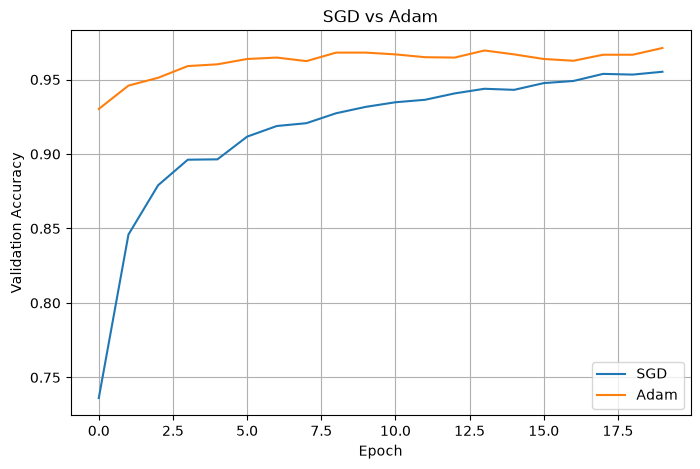

In [194]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_sgd["val_accuracy"],
    label="SGD"
)

plt.plot(
    history_adam["val_accuracy"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("SGD vs Adam")

plt.legend()
plt.grid(True)

plt.show()

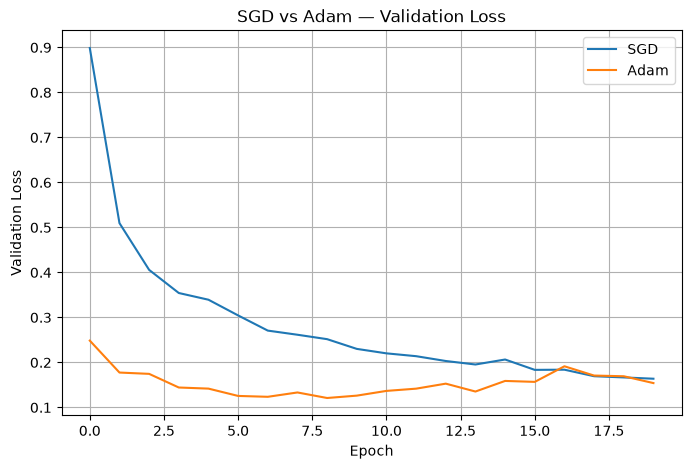

In [195]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_sgd["val_loss"],
    label="SGD"
)

plt.plot(
    history_adam["val_loss"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("SGD vs Adam — Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

## Evaluation

In [196]:

test_loss_sgd, test_accuracy_sgd = evaluate_model(
    X_test,
    y_test_onehot,
    y_test,
    parameters_sgd,
    l2_lambda=0.0001
)

print("SGD Test Loss     :", test_loss_sgd)
print("SGD Test Accuracy :", test_accuracy_sgd)

SGD Test Loss     : 0.14193344816342035
SGD Test Accuracy : 0.9554761904761905


In [197]:

test_loss_adam, test_accuracy_adam = evaluate_model(
    X_test,
    y_test_onehot,
    y_test,
    parameters_adam,
    l2_lambda=0.0001
)

print("Adam Test Loss     :", test_loss_adam)
print("Adam Test Accuracy :", test_accuracy_adam)

Adam Test Loss     : 0.151443198705936
Adam Test Accuracy : 0.9688095238095238


In [198]:

y_pred_sgd = predict(
    X_test,
    parameters_sgd
)

y_pred_adam = predict(
    X_test,
    parameters_adam
)

print("SGD predictions shape :", y_pred_sgd.shape)
print("Adam predictions shape:", y_pred_adam.shape)

SGD predictions shape : (4200,)
Adam predictions shape: (4200,)


In [199]:

from sklearn.metrics import confusion_matrix

cm_sgd = confusion_matrix(
    y_test,
    y_pred_sgd
)

cm_adam = confusion_matrix(
    y_test,
    y_pred_adam
)

print("SGD Confusion Matrix:")
print(cm_sgd)

print("\nAdam Confusion Matrix:")
print(cm_adam)

SGD Confusion Matrix:
[[402   0   2   0   1   3   3   1   0   1]
 [  0 456   1   3   0   0   1   0   7   0]
 [  3   1 393   5   1   0   1   5   7   2]
 [  0   1   3 408   0  12   0   2   5   4]
 [  1   0   0   0 394   0   0   0   1  11]
 [  1   1   0   4   3 358   2   0   6   5]
 [  2   2   3   0   0   6 400   0   1   0]
 [  0   3   1   0   2   0   0 424   2   8]
 [  2   2   2   2   1   6   3   1 383   4]
 [  0   1   0   2   8   1   0   8   4 395]]

Adam Confusion Matrix:
[[410   0   1   0   0   0   1   0   0   1]
 [  0 461   3   0   0   0   0   0   4   0]
 [  0   2 410   2   0   1   0   3   0   0]
 [  0   0   3 418   0   8   0   3   2   1]
 [  0   0   3   1 390   0   3   0   0  10]
 [  1   2   1  12   3 356   1   0   3   1]
 [  0   1   1   0   0   2 410   0   0   0]
 [  0   1   2   0   2   0   0 428   1   6]
 [  2   2   2   6   0   3   0   0 390   1]
 [  0   1   1   1  10   2   0   4   4 396]]


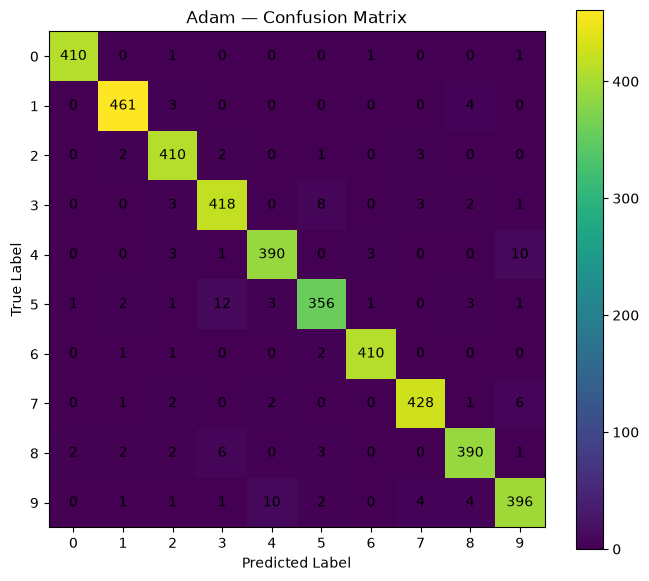

In [200]:

plt.figure(figsize=(8, 7))

plt.imshow(cm_adam)

plt.title("Adam — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    np.arange(10),
    np.arange(10)
)

plt.yticks(
    np.arange(10),
    np.arange(10)
)

plt.colorbar()

for i in range(10):
    
    for j in range(10):
        
        plt.text(
            j,
            i,
            cm_adam[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [201]:
from sklearn.metrics import classification_report

print("SGD CLASSIFICATION REPORT")


print(
    classification_report(
        y_test,
        y_pred_sgd,
        digits=4
    )
)

SGD CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9781    0.9734    0.9757       413
           1     0.9764    0.9744    0.9754       468
           2     0.9704    0.9402    0.9550       418
           3     0.9623    0.9379    0.9499       435
           4     0.9610    0.9681    0.9645       407
           5     0.9275    0.9421    0.9347       380
           6     0.9756    0.9662    0.9709       414
           7     0.9615    0.9636    0.9625       440
           8     0.9207    0.9433    0.9319       406
           9     0.9186    0.9427    0.9305       419

    accuracy                         0.9555      4200
   macro avg     0.9552    0.9552    0.9551      4200
weighted avg     0.9558    0.9555    0.9556      4200



In [202]:

from sklearn.metrics import classification_report

print("ADAM CLASSIFICATION REPORT")


print(
    classification_report(
        y_test,
        y_pred_adam,
        digits=4
    )
)

ADAM CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9927    0.9927    0.9927       413
           1     0.9809    0.9850    0.9829       468
           2     0.9602    0.9809    0.9704       418
           3     0.9500    0.9609    0.9554       435
           4     0.9630    0.9582    0.9606       407
           5     0.9570    0.9368    0.9468       380
           6     0.9880    0.9903    0.9891       414
           7     0.9772    0.9727    0.9749       440
           8     0.9653    0.9606    0.9630       406
           9     0.9519    0.9451    0.9485       419

    accuracy                         0.9688      4200
   macro avg     0.9686    0.9683    0.9684      4200
weighted avg     0.9688    0.9688    0.9688      4200



In [203]:

class_accuracy = {}

for digit in range(10):
    
    mask = (
        y_test == digit
    )
    
    correct = np.sum(
        y_pred_adam[mask] == digit
    )
    
    total = np.sum(mask)
    
    class_accuracy[digit] = (
        correct / total
    )

for digit, acc in class_accuracy.items():
    
    print(
        f"Digit {digit}: "
        f"{acc:.4f}"
    )

Digit 0: 0.9927
Digit 1: 0.9850
Digit 2: 0.9809
Digit 3: 0.9609
Digit 4: 0.9582
Digit 5: 0.9368
Digit 6: 0.9903
Digit 7: 0.9727
Digit 8: 0.9606
Digit 9: 0.9451


In [204]:

misclassified_indices = np.where(
    y_pred_adam != y_test
)[0]

print(
    "Number of misclassified images:",
    len(misclassified_indices)
)

Number of misclassified images: 131


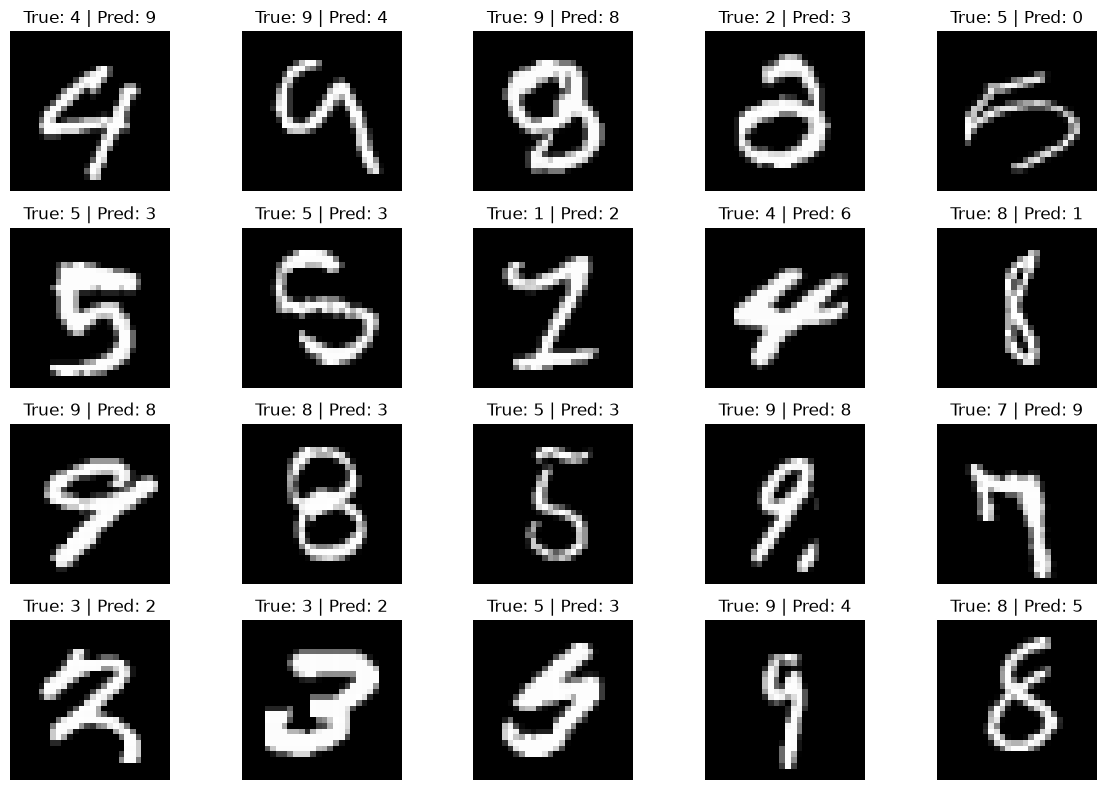

In [205]:

num_images = 20

selected_indices = (
    misclassified_indices[:num_images]
)

plt.figure(figsize=(12, 8))

for i, index in enumerate(
    selected_indices
):
    
    plt.subplot(4, 5, i + 1)
    
    image = X_test[index].reshape(
        28, 28
    )
    
    plt.imshow(
        image,
        cmap="gray"
    )
    
    plt.title(
        f"True: {y_test[index]} | "
        f"Pred: {y_pred_adam[index]}"
    )
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [206]:

print("=" * 55)
print("              SGD VS ADAM")
print("=" * 55)

print(
    f"{'Metric':<25}"
    f"{'SGD':>15}"
    f"{'Adam':>15}"
)

print("-" * 55)

print(
    f"{'Test Loss':<25}"
    f"{test_loss_sgd:>15.4f}"
    f"{test_loss_adam:>15.4f}"
)

print(
    f"{'Test Accuracy':<25}"
    f"{test_accuracy_sgd:>15.4f}"
    f"{test_accuracy_adam:>15.4f}"
)

              SGD VS ADAM
Metric                               SGD           Adam
-------------------------------------------------------
Test Loss                         0.1419         0.1514
Test Accuracy                     0.9555         0.9688


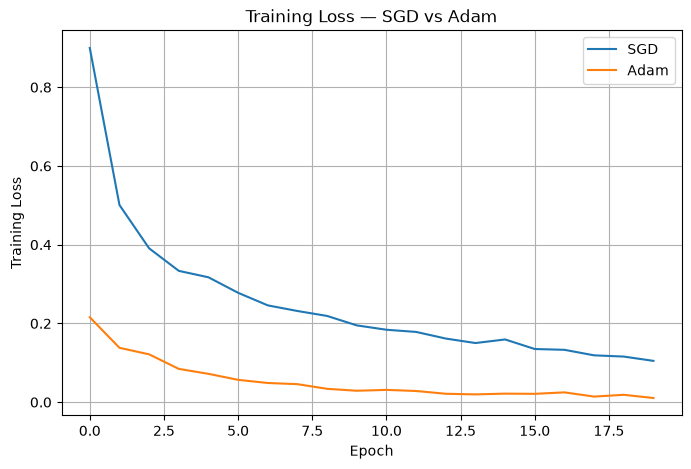

In [207]:

plt.figure(figsize=(8, 5))

plt.plot(
    history_sgd["train_loss"],
    label="SGD"
)

plt.plot(
    history_adam["train_loss"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss — SGD vs Adam")

plt.legend()
plt.grid(True)

plt.show()

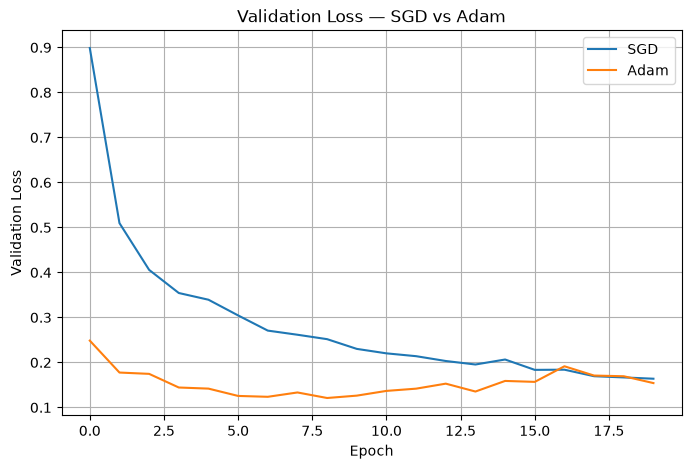

In [208]:

plt.figure(figsize=(8, 5))

plt.plot(
    history_sgd["val_loss"],
    label="SGD"
)

plt.plot(
    history_adam["val_loss"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss — SGD vs Adam")

plt.legend()
plt.grid(True)

plt.show()

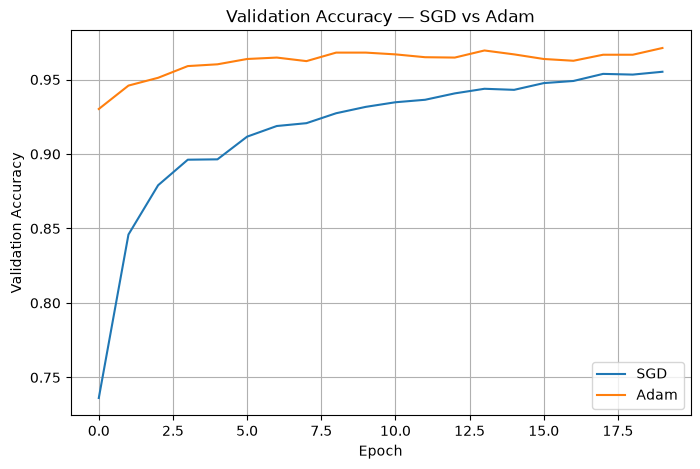

In [209]:

plt.figure(figsize=(8, 5))

plt.plot(
    history_sgd["val_accuracy"],
    label="SGD"
)

plt.plot(
    history_adam["val_accuracy"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy — SGD vs Adam")

plt.legend()
plt.grid(True)

plt.show()